<a href="https://colab.research.google.com/github/Sairishithreddyvem/ml/blob/main/ml_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df=pd.read_csv('/content/gender_submission.csv')
df


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0


In [4]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    data[col] = encoder.fit_transform(data[col])


In [5]:
x=df.iloc[:,0]
y=df.iloc[:,1]

In [6]:
import numpy as np
x=np.array(x).reshape(-1,1)
y=np.array(y).reshape(-1,1)


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
model=LogisticRegression(class_weight='balanced')


In [10]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced')

In [11]:
y_pred=model.predict(x_test)

In [12]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [13]:
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 0.5238095238095238


In [14]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print("confusion matrix:")
print('TP FP')
print('FN TN')
print(cm)

confusion matrix:
TP FP
FN TN
[[26 24]
 [16 18]]


In [15]:
precision=precision_score(y_test,y_pred,zero_division=0)
recall=recall_score(y_test,y_pred,zero_division=0)
f1=f1_score(y_test,y_pred,zero_division=0)
print("Precision",precision)
print("Recall",recall)
print("F1 Score",f1)

Precision 0.42857142857142855
Recall 0.5294117647058824
F1 Score 0.47368421052631576


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
cm=confusion_matrix(y_test,y_pred,labels=[1,0])


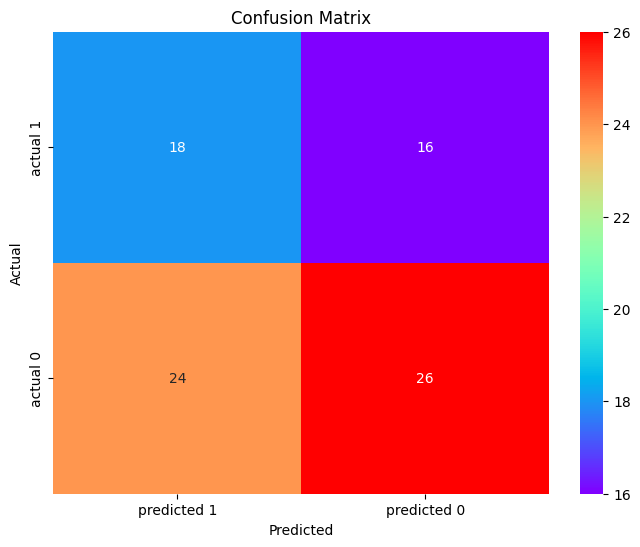

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='rainbow',xticklabels=['predicted 1','predicted 0'],yticklabels=['actual 1','actual 0'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
from sklearn.metrics import roc_curve,auc

In [20]:
y_prob=model.predict_proba(x_test)[:,1]

In [21]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

In [22]:
roc_auc=auc(fpr,tpr)

In [23]:
print("AUC",roc_auc)

AUC 0.5229411764705882


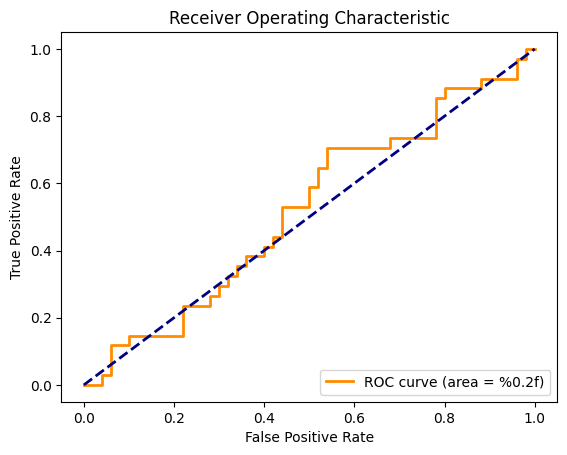

In [24]:
plt.figure()
plt.plot(fpr,tpr,color='darkorange',lw=2,label='ROC curve (area = %0.2f)' .format(roc_auc))
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()